# GECCO 2026 TUTORIAL
 ---
 
# Advances in Multi-Objective Optimization and Decision-Making

# Demo on$-$ Machine-DM: Machine Learning-Based Decision-Makers 
 --- 
 
## Presenters: Deepanshu Yadav, Kalyanmoy Deb

---
---

# Computing Pareto-optimal Solutions using $pymoo$

## Visit: https://pymoo.org/

In [1]:
%pip install pymoo

## Import Following Libraries

In [2]:
import numpy as np
# 1. Hotfix for NumPy 2.0 compatibility with older pymoo
np.float = float 
np.int = int  # <-- ADD THIS LINE HERE

# 2. Standard math and data tools
import math as ma
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# 3. Correct v0.4.1 import paths
from pymoo.factory import get_problem, get_reference_directions
from pymoo.algorithms.nsga2 import NSGA2
from pymoo.algorithms.nsga3 import NSGA3
from pymoo.model.problem import Problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

from pymoo.configuration import Configuration
Configuration.show_compile_hint = False

/lib/python3.13/site-packages/pymoo/model/problem.py:364: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif _type is "starmap":


In [3]:
class MyProblem(Problem):

    def __init__(self):
        super().__init__(n_var=5,
                         n_obj=2,
                         n_constr=0,  # Updated from n_ieq_constr for v0.4.1
                         xl=np.array([0, 0, 0, 0, 0]),
                         xu=np.array([1, 1, 1, 1, 1]))

    def _evaluate(self, X, out, *args, **kwargs):
        # X is a matrix of shape (1000, 5)
        K = 5
        
        # 1. Slice columns (X[:, i]) instead of rows to process all solutions simultaneously
        x0 = X[:, 0]
        
        # 2. Vectorize the math using NumPy operations (np.pi, np.cos, np.sin)
        r = 5 + 10 * ((x0 - 0.5) ** 2) + np.cos(2 * K * np.pi * x0) / K
        g = 1 + 9 / 4 * (X[:, 1] + X[:, 2] + X[:, 3] + X[:, 4])
        
        f1 = g * r * np.sin(np.pi * x0 / 2)  # Objective 1 array for all solutions
        f2 = g * r * np.cos(np.pi * x0 / 2)  # Objective 2 array for all solutions

        # 3. Use column_stack to output a clean (1000, 2) matrix
        out["F"] = np.column_stack([f1, f2])

knee_problem = MyProblem()

In [4]:
algorithm = NSGA2(pop_size=200)

res = minimize(knee_problem,
               algorithm,
               ("n_gen",100),
               verbose=True,
               seed=1)

n_gen |  n_eval |  n_nds  | delta_ideal  | delta_nadir  |   delta_f   
    1 |     200 |      10 |            - |            - |            -
    2 |     400 |       9 |  0.003015732 |  0.697882552 |  0.105787995
    3 |     600 |      10 |  0.000145590 |  0.481330536 |  0.087864029
    4 |     800 |      12 |  0.013387038 |  1.206278484 |  0.056082344
    5 |    1000 |      16 |  0.000490508 |  0.316254138 |  0.045523722
    6 |    1200 |      16 |  0.000016020 |  0.018625132 |  0.034017604
    7 |    1400 |      18 |  0.000450536 |  0.035235672 |  0.022541609
    8 |    1600 |      25 |  0.000371828 |  0.138213066 |  0.037625965
    9 |    1800 |      21 |  0.000068158 |  0.669512876 |  0.049656351
   10 |    2000 |      20 |  0.000104542 |  0.127086145 |  0.033328785
   11 |    2200 |      22 |  0.000019915 |  0.815163673 |  0.032016162
   12 |    2400 |      25 |  0.000024966 |  0.288217057 |  0.035823723
   13 |    2600 |      25 |  1.72833E-06 |  0.658908241 |  0.019605417
   14 

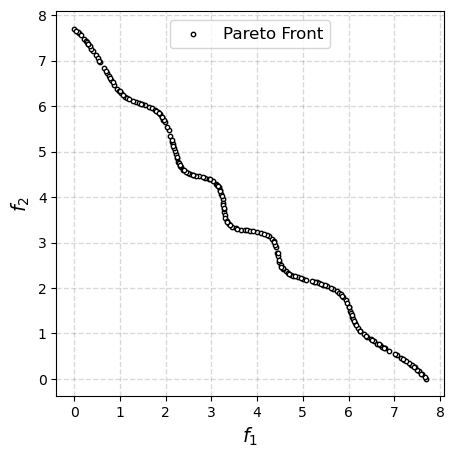

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.scatter(res.F[:, 0], res.F[:, 1], s=10, label='Pareto Front', edgecolor='k', facecolor='w', alpha=1)
plt.legend(["Pareto Front"], loc ="upper center",fontsize=12)

plt.xlabel('$f_1$',fontsize=14)
plt.ylabel('$f_2$',fontsize=14)
plt.grid(color='k', linestyle='--', linewidth=1, alpha=0.15)

In [6]:
ideal_point = np.array([np.min(res.F[:,0]), np.min(res.F[:,1])])
nadir_point = np.array([np.max(res.F[:,0]), np.max(res.F[:,1])])
print("Ideal Point:", np.round(ideal_point,4), "and Nadir Point:", np.round(nadir_point,4))

Ideal Point: [0. 0.] and Nadir Point: [7.7001 7.7002]


# Interactive MCDM Problem

## Consider unknown worst point: $R$ = [6.5, 6.0] and corresponding target point

In [7]:
ref_point = np.array([6.5,5.0])

pf = res.F
asf_values = (pf-ideal_point)/(ref_point-ideal_point) + 0.01*np.sum(pf/(nadir_point-ideal_point))
ASF=np.zeros(len(asf_values))
for i in range(0,len(asf_values)):
    ASF[i] = np.max(asf_values[i,:])
    
idx = np.argmin(ASF)
Fin_F = pf[idx,:]

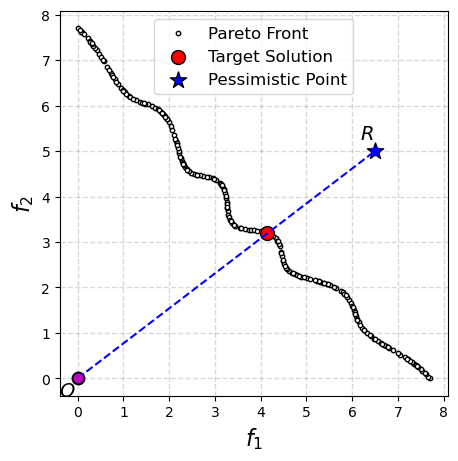

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.scatter(res.F[:, 0], res.F[:, 1], s=10, label='Pareto Front', edgecolor='k', facecolor='w', alpha=1)
plt.scatter(res.F[idx, 0], res.F[idx, 1], s=100, label='Target Solution', edgecolor='k', facecolor='r', alpha=1)

sc2 = plt.scatter(ref_point[0],ref_point[1], s=150,  label='Pessimistic Point', marker='*',edgecolor='k',facecolor='b',alpha=1)
sc3 = plt.scatter(ideal_point[0],ideal_point[1],s=80,edgecolor='k',facecolor='k',alpha=1)

plt.plot([ideal_point[0], ref_point[0]], [ideal_point[1], ref_point[1]], 'bo', linestyle="--")
plt.plot([ideal_point[0]], [ideal_point[1]], 'mo', linestyle="--")
plt.text(0.95*ref_point[0], 1.05*ref_point[1], "$R$", fontsize=14)
plt.text(ideal_point[0]-0.4,  ideal_point[1]-0.4, "$O$", fontsize=14)

plt.legend(["Pareto Front", "Target Solution", "Pessimistic Point"], loc ="upper center",fontsize=12)

plt.xlabel('$f_1$',fontsize=16)
plt.ylabel('$f_2$',fontsize=16)
plt.grid(color='k', linestyle='--', linewidth=1, alpha=0.15)
# plt.savefig("Bench_MCDM Knee-2d.pdf", format="pdf", bbox_inches="tight")

## Unknown Objective Classes

In [9]:
eps = ref_point 
delta = 0.035*(nadir_point-ideal_point) 
d = Fin_F 

## Plot function

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_2D(curr):
    plt.figure(figsize=(5.5, 5.5))
    
    # Plotting Data Arrays
    plt.scatter(pf[:, 0], pf[:, 1], s=10, label='Pareto Front', edgecolor='k', facecolor='w', alpha=1)
    plt.scatter(pf[curr, 0], pf[curr, 1], s=100, label='Current Solution', edgecolor='k', facecolor='b', alpha=1)
    plt.scatter(pf[idx, 0], pf[idx, 1], s=150, label='Target Solution', edgecolor='k', facecolor='r', alpha=1)

    # --- VERTICAL BOUNDARIES & LABELS (f1 Axis) ---
    plt.axvline(x=eps[0], color='r', linewidth=1.5, linestyle=':')
    plt.text(eps[0] + 0.35, 0.15, r'$I^{<}:1$', rotation=90, color='k', va='center', fontsize=12)
    plt.text(eps[0] - 0.55, 0.15, r'$I^{\leq}:2$', rotation=90, color='k', va='center', fontsize=12)

    plt.axvline(x=Fin_F[0] + delta[0], color='y', linewidth=1.5, linestyle=':')
    plt.axvline(x=Fin_F[0] - delta[0], color='y', linewidth=1.5, linestyle=':')
    plt.text(Fin_F[0] + delta[0] - 0.30, 0.15, r'$I^{=}:3$', rotation=90, color='k', va='center', fontsize=12)

    plt.axvline(x=d[0], color='g', linewidth=1.5, linestyle=':')
    plt.text(d[0] - 1.35, 0.15, r'$I^{\geq}:4$', rotation=90, color='k', va='center', fontsize=12)

    # --- HORIZONTAL BOUNDARIES & LABELS (f2 Axis) ---
    plt.axhline(y=eps[1], color='r', linewidth=1.5, linestyle=':')
    plt.text(7, eps[1] + 0.35, r'$I^{<}:1$', rotation=0, color='k', va='center', fontsize=12)
    plt.text(7, eps[1] - 0.35, r'$I^{\leq}:2$', rotation=0, color='k', va='center', fontsize=12)

    plt.axhline(y=Fin_F[1] + delta[1], color='y', linewidth=1.5, linestyle=':')
    plt.axhline(y=Fin_F[1] - delta[1], color='y', linewidth=1.5, linestyle=':')
    # FIX: Swapped Fin_F[0] to Fin_F[1] so the text aligns vertically on the y-axis property
    plt.text(7, Fin_F[1] + delta[1] - 1.30, r'$I^{=}:3$', rotation=0, color='k', va='center', fontsize=12)

    plt.axhline(y=d[1], color='g', linewidth=1.5, linestyle=':')
    plt.text(7, d[1] - 1.35, r'$I^{\geq}:4$', rotation=0, color='k', va='center', fontsize=12)

    # --- REFERENCE AND IDEAL POINT HIGHLIGHTS ---
    sc2 = plt.scatter(ref_point[0], ref_point[1], s=150, marker='*', edgecolor='k', facecolor='k', alpha=1)
    sc3 = plt.scatter(ideal_point[0], ideal_point[1], s=80, edgecolor='k', facecolor='k', alpha=1)

    plt.plot([ideal_point[0], ref_point[0]], [ideal_point[1], ref_point[1]], 'bo', linestyle="--")
    plt.plot([ideal_point[0]], [ideal_point[1]], 'mo', linestyle="--")
    
    plt.text(0.95 * ref_point[0], 1.05 * ref_point[1], "$R$", fontsize=14)
    plt.text(ideal_point[0] - 0.4, ideal_point[1] - 0.4, "$O$", fontsize=14)

    # --- CANVAS CONFIGURATION ---
    plt.legend(["Pareto Front", "MCDM Solution", "Target Solution"], loc="upper center", fontsize=10)
    plt.xlabel('$f_1$', fontsize=14)
    plt.ylabel('$f_2$', fontsize=14)
    plt.grid(color='k', linestyle='--', linewidth=1, alpha=0.15)
    plt.show()

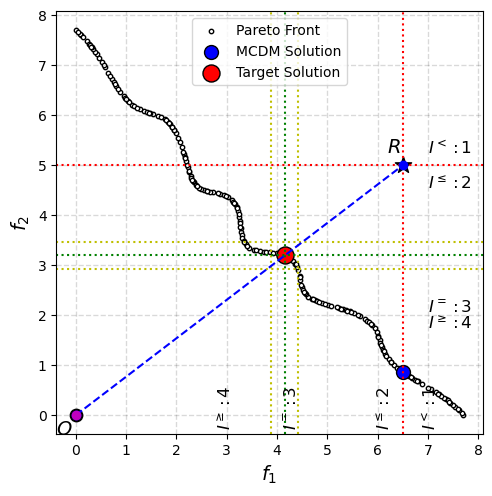

In [12]:
curr = 125 # 0, 25, 500, 990
plot_2D(curr)

# Testing Machine-DM using Pre-trained ANNs

------

## Import Following Libraries

In [13]:
import piplite
await piplite.install(['h5py'])

In [14]:
# from tensorflow import keras
import os
import joblib
import json
import pickle
import h5py
import sklearn

## Load ANNs and Scalars

In [118]:
import h5py
import numpy as np

def load_pure_shape_weights(h5_path, model_version, structure_json=None):
    """
    Dynamically maps weight arrays from an H5 file while explicitly checking
    for transposed layout storage to safeguard standard matrix dot products.
    """
    if structure_json and "config" in structure_json and "layers" in structure_json["config"]:
        backbone_dims = []
        layers_list = structure_json["config"]["layers"]
        for layer in layers_list:
            layer_config = layer.get("config", {})
            if layer.get("class_name") == "Dense" or "units" in layer_config:
                units = layer_config.get("units")
                if not backbone_dims and "batch_input_shape" in layer_config:
                    backbone_dims.append(layer_config["batch_input_shape"][-1])
                elif not backbone_dims:
                    backbone_dims.append(5)
                if units not in [1, 4]:
                    backbone_dims.append(units)
        if 16 not in backbone_dims:
            backbone_dims.append(16)
        head_out_dim = 4 if model_version == 1 else 1
    else:
        backbone_dims = [5, 128, 64, 32, 16]
        head_out_dim = 4 if model_version == 1 else 1

    expected_shapes = {}
    for i in range(len(backbone_dims) - 1):
        expected_shapes[f'd{i+1}_W'] = (backbone_dims[i], backbone_dims[i+1])
        expected_shapes[f'd{i+1}_b'] = (backbone_dims[i+1],)

    weights = {}
    unmatched_kernels = []
    unmatched_biases = []
    
    with h5py.File(h5_path, 'r') as f:
        def walk_h5(name, obj):
            if isinstance(obj, h5py.Dataset):
                arr = np.array(obj)
                clean_name = name.lower()
                
                # Assign multi-head outputs cleanly by path name
                if 'out1' in clean_name and ('kernel' in clean_name or arr.ndim == 2):
                    # Check if head shape is transposed (4, 16) instead of (16, 4)
                    weights['out1_W'] = arr if arr.shape == (16, head_out_dim) else arr.T
                elif 'out1' in clean_name and ('bias' in clean_name or arr.ndim == 1):
                    weights['out1_b'] = arr
                elif 'out2' in clean_name and ('kernel' in clean_name or arr.ndim == 2):
                    weights['out2_W'] = arr if arr.shape == (16, head_out_dim) else arr.T
                elif 'out2' in clean_name and ('bias' in clean_name or arr.ndim == 1):
                    weights['out2_b'] = arr
                elif 'kernel' in clean_name or 'weight' in clean_name or arr.ndim == 2:
                    unmatched_kernels.append(arr)
                elif 'bias' in clean_name or arr.ndim == 1:
                    unmatched_biases.append(arr)
        f.visititems(walk_h5)

    # Map backbone elements while automatically healing transposed orientations
    for key, expected_shape in expected_shapes.items():
        if key.endswith('_W'):
            # Look for exact or flipped shape dimension pairs
            flipped_shape = (expected_shape[1], expected_shape[0])
            for arr in unmatched_kernels:
                if arr.shape == expected_shape:
                    weights[key] = arr
                    break
                elif arr.shape == flipped_shape:
                    weights[key] = arr.T  # Transpose back to expected layout!
                    break
        else:
            for arr in unmatched_biases:
                if arr.shape == expected_shape:
                    weights[key] = arr
                    break

    return weights

In [119]:
import json

# 1. Load Structural Blueprints
with open('ANN1_structure.json', 'r') as f:
    ann1_structure = json.load(f)

with open('ANN2_structure.json', 'r') as f:
    ann2_structure = json.load(f)

# 2. Load the StandardScaler configuration JSON parameters
with open('scalers.json', 'r') as f:
    scaler_json = json.load(f)

# 3. Extract pure matrix weights dynamically guided by structural blueprints
ann1_data = load_pure_shape_weights("ANN1_weights.h5", model_version=1, structure_json=ann1_structure)
ann2_data = load_pure_shape_weights("ANN2_weights.h5", model_version=2, structure_json=ann2_structure)

print("✓ Pipeline configurations ready!")
print("Scaler Type Found:  ", scaler_json.get('type'))
print("ANN1 Classification Keys:", sorted(list(ann1_data.keys())))
print("ANN2 Regression Keys:    ", sorted(list(ann2_data.keys())))

✓ Pipeline configurations ready!
Scaler Type Found:   standard
ANN1 Classification Keys: ['d1_W', 'd1_b', 'd2_W', 'd2_b', 'd3_W', 'd3_b', 'd4_W', 'd4_b', 'out1_W', 'out1_b', 'out2_W', 'out2_b']
ANN2 Regression Keys:     ['d1_W', 'd1_b', 'd2_W', 'd2_b', 'd3_W', 'd3_b', 'd4_W', 'd4_b', 'out1_W', 'out1_b', 'out2_W', 'out2_b']


In [120]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def evaluate_deep_ann1(X_input, w):
    """Evaluates ANN1 (Model 16) -> Outputs two sets of 4 class probabilities"""
    X = np.atleast_2d(X_input)
    
    # Forward pass through shared hidden layers
    h1 = relu(np.dot(X,  w['d1_W']) + w['d1_b'])
    h2 = relu(np.dot(h1, w['d2_W']) + w['d2_b'])
    h3 = relu(np.dot(h2, w['d3_W']) + w['d3_b'])
    h4 = relu(np.dot(h3, w['d4_W']) + w['d4_b'])
    
    # Process both classification branches independently
    logits_f1 = np.dot(h4, w['out1_W']) + w['out1_b']  # Class logits for f1
    logits_f2 = np.dot(h4, w['out2_W']) + w['out2_b']  # Class logits for f2
    
    # Return probabilities for both objectives
    return softmax(logits_f1), softmax(logits_f2)

def evaluate_deep_ann2(X_input, w):
    """Evaluates ANN2 (Model 17) -> Outputs 2 Bounding Parameters via Column Stack"""
    X = np.atleast_2d(X_input)
    h1 = relu(np.dot(X,  w['d1_W']) + w['d1_b'])
    h2 = relu(np.dot(h1, w['d2_W']) + w['d2_b'])
    h3 = relu(np.dot(h2, w['d3_W']) + w['d3_b'])
    h4 = relu(np.dot(h3, w['d4_W']) + w['d4_b'])
    
    out1 = np.dot(h4, w['out1_W']) + w['out1_b'] # Single neuron output column 1
    out2 = np.dot(h4, w['out2_W']) + w['out2_b'] # Single neuron output column 2
    
    return np.column_stack([out1, out2])

## Call pretrained ANN1 for a specific problem (Crash worthiness here)

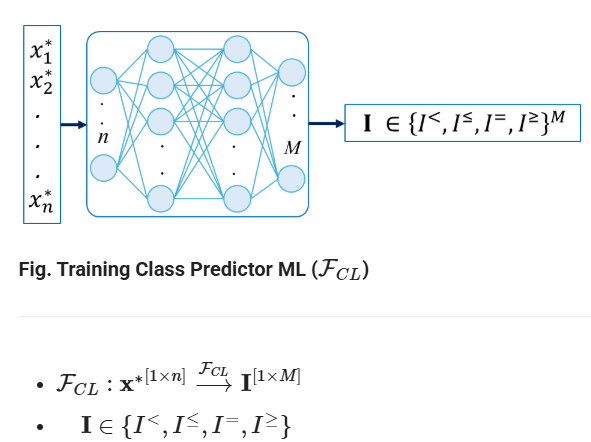

## Call pretrained ANN2 for a specific problem (Crash worthiness here)

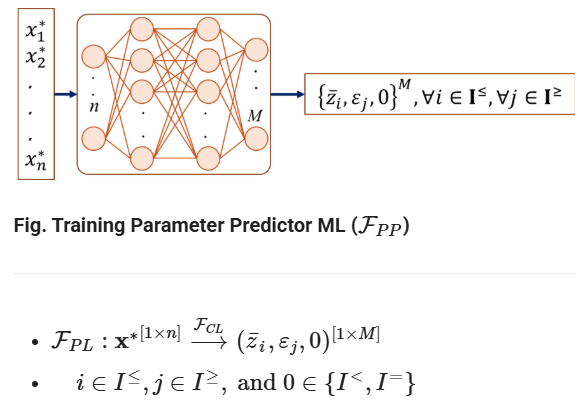

In [121]:
print("--- ANN1 Weights ---")
for k, v in ann1_data.items():
    print(f"{k:<10} shape: {v.shape}")

print("\n--- ANN2 Weights ---")
for k, v in ann2_data.items():
    print(f"{k:<10} shape: {v.shape}")

--- ANN1 Weights ---
out1_b     shape: (4,)
out1_W     shape: (16, 4)
out2_b     shape: (4,)
out2_W     shape: (16, 4)
d1_W       shape: (5, 128)
d1_b       shape: (128,)
d2_W       shape: (128, 64)
d2_b       shape: (64,)
d3_W       shape: (64, 32)
d3_b       shape: (32,)
d4_W       shape: (32, 16)
d4_b       shape: (16,)

--- ANN2 Weights ---
out1_b     shape: (1,)
out1_W     shape: (16, 1)
out2_b     shape: (1,)
out2_W     shape: (16, 1)
d1_W       shape: (5, 128)
d1_b       shape: (128,)
d2_W       shape: (128, 64)
d2_b       shape: (64,)
d3_W       shape: (64, 32)
d3_b       shape: (32,)
d4_W       shape: (32, 16)
d4_b       shape: (16,)


## Function: Given PO solution $X$, predicts $I$ and $[\bar{z},$ $\varepsilon]$ Using ANN1 and ANN2

In [122]:
with open('scalers.json', 'r') as f:
    scaler_json = json.load(f)
print(f"  Scaler Parameters: {list(scaler_json.keys())}")

  Scaler Parameters: ['type', 'X_param1', 'X_param2', 'Y_param1', 'Y_param2']


In [134]:
import numpy as np

def Output_MachDM_Pref_Browser(ann1_data, ann2_data, X_current, scaler_json, pf_input=None):
    """
    Browser-safe neural network preference wrapper.
    - ANN1 (Classifier) receives raw UNSCALED variables.
    - ANN2 (Regressor) receives standard Z-score SCALED variables.
    """
    X_current = np.atleast_2d(X_current)
    X_current = np.round(X_current, 4)
    
    # 1. SCALE FOR ANN2 REGRESSOR ONLY
    x_mean = np.array(scaler_json.get('X_param1'), dtype=np.float64)
    x_std  = np.array(scaler_json.get('X_param2'), dtype=np.float64)
    X_scaled = (X_current - x_mean) / (x_std + 1e-7)

    # 2. RUN PASSES (ANN1 uses unscaled X_current, ANN2 uses scaled X_scaled)
    probs_f1, probs_f2 = evaluate_deep_ann1(X_current, ann1_data)
    raw_params = evaluate_deep_ann2(X_scaled, ann2_data)
    
    # 3. MANUAL INVERSE STANDARD SCALING FOR ANN2 REGRESSION PARAMETERS
    y_mean = np.array(scaler_json.get('Y_param1'), dtype=np.float64)
    y_std  = np.array(scaler_json.get('Y_param2'), dtype=np.float64)
    
    unscaled_matrix = (raw_params * y_std) + y_mean
    unscaled_params = unscaled_matrix.flatten()
    
    # 4. EXTRACT 1-INDEXED CLASS SELECTIONS SAFELY FROM FLATTENED 1D ARRAYS
    p1_flat = np.squeeze(probs_f1)
    p2_flat = np.squeeze(probs_f2)
    
    class_f1 = int(np.argmax(p1_flat) + 1)
    class_f2 = int(np.argmax(p2_flat) + 1)
    pred_class = [class_f1, class_f2]
    
    # 5. ASSIGN SEPARATE BINS
    I_dict = {1: [], 2: [], 3: [], 4: []}
    I_dict[class_f1].append(0)
    I_dict[class_f2].append(1)
            
    return pred_class, unscaled_params.tolist(), I_dict

## A Sample Example

In [136]:
import numpy as np

# 1. Format the current design space solution into a clean 2D array (Shape: 1, 5)
X_solns = np.atleast_2d(res.X[curr, :])


# 2. Run the shape-pure multi-task browser architecture
pred_class, pred_params, I = Output_MachDM_Pref_Browser(
    ann1_data=ann1_data, 
    ann2_data=ann2_data, 
    X_current=X_solns, 
    scaler_json=scaler_json,
    pf_input=pf[curr, :]
)

# 3. Print your properly partitioned multi-class results
print("Final Predicted Class Vector from ANN1:", pred_class)
print("Predicted Bounding Parameter Vector from ANN2:", pred_params)
print("-" * 60)
print(f"Index of Class 1: {I[1]} | Class 2: {I[2]} | Class 3: {I[3]} | Class 4: {I[4]}")
print("=" * 60)

Final Predicted Class Vector from ANN1: [2, 4]
Predicted Bounding Parameter Vector from ANN2: [6.078939843446852, 1.439596872677806]
------------------------------------------------------------
Index of Class 1: [] | Class 2: [0] | Class 3: [] | Class 4: [1]


# Implementing Machine-DM with STEM Method

In [125]:
import numpy as np

class STEM_Problem(Problem):
    def __init__(self, problem=None, start_F=None, eps=None, i1=None, i2=None, i3=None, i4=None, mode=None,
                 ideal_point=None, nadir_point=None):
        
        self.problem = problem
        self.start_F = np.array(start_F) if start_F is not None else np.array([])
        self.eps = np.array(eps) if eps is not None else np.array([])

        self.i1 = np.array(i1, dtype=int) if i1 is not None else np.array([], dtype=int)
        self.i2 = np.array(i2, dtype=int) if i2 is not None else np.array([], dtype=int)
        self.i3 = np.array(i3, dtype=int) if i3 is not None else np.array([], dtype=int)
        self.i4 = np.array(i4, dtype=int) if i4 is not None else np.array([], dtype=int)
        self.mode = mode

        self.ideal_point = np.array(ideal_point) if ideal_point is not None else np.array([])
        self.nadir_point = np.array(nadir_point) if nadir_point is not None else np.array([])
        self.rho = 0.001
        
        # Calculate structural number of math constraints added by STEM groups
        self.n_stem_constr = len(self.i1) + len(self.i2) + len(self.i3) + len(self.i4)
        base_n_constr = getattr(problem, "n_constr", 0)

        # Initialize base Problem properties explicitly
        super().__init__(
            n_var=self.problem.n_var if problem is not None else 0,
            n_obj=1,  # STEM scalarizes the objectives down to a single minimax function
            n_constr=base_n_constr + self.n_stem_constr,
            xl=self.problem.xl if problem is not None else 0.0,
            xu=self.problem.xu if problem is not None else 1.0
        )

    def _evaluate(self, X, out, *args, **kwargs):
        # 1. Forward evaluate the baseline problem in bulk
        base_out = {}
        self.problem._evaluate(X, base_out)
        
        F_base = np.atleast_2d(base_out.get("F"))  # Shape: (pop_size, base_n_obj)
        G_base = base_out.get("G")                 # Shape: (pop_size, base_n_constr) or None
        
        pop_size = X.shape[0]
        n_obj_base = F_base.shape[1]

        # Ensure index lists fall safely within real objective limits
        if len(self.i1) == 0 and len(self.i2) == 0 and len(self.i3) == 0 and len(self.i4) == 0:
            i1234 = np.arange(n_obj_base)
        else:
            i1234 = np.concatenate([self.i1, self.i2, self.i3, self.i4])
        i1234 = i1234[i1234 < n_obj_base]

        # ----------------========================================================
        # MODE: START
        # ----------------========================================================
        if self.mode == 'start':
            denom = self.nadir_point[i1234] - self.ideal_point[i1234] + 1e-8
            
            # Vectorized broadcast over population row elements
            norm_terms = (F_base[:, i1234] - self.start_F[i1234]) / denom
            reg_terms = self.rho * np.sum(F_base[:, i1234] / denom, axis=1, keepdims=True)
            
            out["F"] = np.max(norm_terms, axis=1) + reg_terms.flatten()
            if G_base is not None:
                out["G"] = G_base

        # ----------------========================================================
        # MODE: SUBPROBLEM
        # ----------------========================================================
        elif self.mode == 'sub':
            e = (self.nadir_point - self.ideal_point) / (self.nadir_point * (self.ideal_point + 0.001))
            w = e / (np.sum(e) + 1e-8)
            
            # Suppress tracking weights for compromised classifications
            valid_i4 = self.i4[self.i4 < len(w)]
            valid_i3 = self.i3[self.i3 < len(w)]
            w[valid_i4] = 0.0
            w[valid_i3] = 0.0

            # Vectorized generation of STEM restriction inequalities
            G_step_list = []
            
            # Group 1 & 2 bounds: f_i(x) <= f_i(x_start)
            i12 = np.concatenate([self.i1, self.i2])
            i12 = i12[i12 < n_obj_base]
            if len(i12) > 0:
                G_step_list.append(F_base[:, i12] - self.start_F[i12])

            # Group 3 bounds: f_j(x) <= f_j(x_start)
            i3_valid = self.i3[self.i3 < n_obj_base]
            if len(i3_valid) > 0:
                G_step_list.append(F_base[:, i3_valid] - self.start_F[i3_valid])

            # Group 4 bounds: f_k(x) <= epsilon_k
            i4_valid = self.i4[(self.i4 < n_obj_base) & (self.i4 < len(self.eps))]
            if len(i4_valid) > 0:
                G_step_list.append(F_base[:, i4_valid] - self.eps[i4_valid])

            # Scalarize Chebyshev distance vector min-max target
            out["F"] = np.max(np.abs(w[i1234] * (F_base[:, i1234] - self.ideal_point[i1234])), axis=1)

            # Consolidate baseline problem constraints with new preference steps
            if len(G_step_list) > 0:
                G_step = np.column_stack(G_step_list)
                if G_base is not None and len(G_base) > 0:
                    out["G"] = np.column_stack([G_base, G_step])
                else:
                    out["G"] = G_step
            else:
                if G_base is not None:
                    out["G"] = G_base

        else:
            raise ValueError("mode must be either 'start' or 'sub'")

## AASF for Start Point

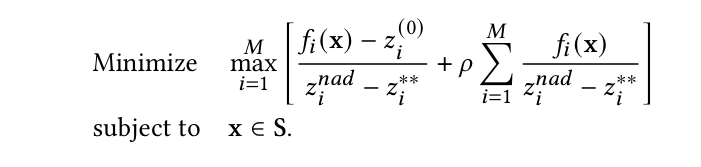

In [109]:
import numpy as np
from pymoo.algorithms.so_genetic_algorithm import GA
from pymoo.factory import get_termination
from pymoo.optimize import minimize

def STEM_Start_Point_Browser(problem, Start_point_X, pop_size, n_gen, xl, xu, 
                             ideal_point,nadir_point,ann1_data, ann2_data,scaler_json):
    
    # Check baseline constraint properties
    n_ieq_constr = getattr(problem, "n_ieq_constr", 0)
    n_eq_constr = getattr(problem, "n_eq_constr", 0)
    n_cons = n_ieq_constr + n_eq_constr
    
    # 1. Forward evaluate initial point safely
    raw_eval = problem.evaluate(Start_point_X)
    STEM_Start_F1 = raw_eval[0] if n_cons >= 1 else raw_eval
    
    # 2. Instantiate the vectorized STEM problem wrapper
    STEM_Method_Start = STEM_Problem(
        problem=problem, start_F=STEM_Start_F1, mode='start', 
        ideal_point=ideal_point, nadir_point=nadir_point
    )
    
    # 3. Configure Pymoo GA and execution engine
    algorithm = GA(pop_size=pop_size, eliminate_duplicates=True)
    termination = get_termination("n_gen", n_gen)
    
    print("=" * 100)
    print("Running high-fidelity initialization via Pymoo GA Engine...")
    
    res_STEM_Start = minimize(
        STEM_Method_Start,
        algorithm,
        termination=termination,
        seed=1,
        verbose=False
    )
    
    print("Optimization Completed ...")
    print("=" * 100)
    
    # 4. Extract final optimized startup solutions
    if res_STEM_Start.X is None:
        print("No solution found by GA ... Fallback to initial seed execution.")
        STEM_Start_X = Start_point_X
    else:
        STEM_Start_X = res_STEM_Start.X
        
    print("Start Point X:", STEM_Start_X)
    
    # Re-evaluate final F metric vector coordinate
    raw_final_eval = problem.evaluate(STEM_Start_X)
    STEM_Start_F = raw_final_eval[0] if n_cons >= 1 else raw_final_eval
    print("Start Point F:", STEM_Start_F)
    
    # 5. Route through our shape-pure multi-task browser evaluators
    pred_class, pred_params, I = Output_MachDM_Pref_Browser(
        ann1_data=ann1_data, 
        ann2_data=ann2_data, 
        scaler_json=scaler_json,
        X_current=np.atleast_2d(STEM_Start_X)
    )
    
    print("Objective Classifications:", pred_class)
    print('Parameters:', pred_params)
    print("Class-wise Objectives i's:", I)
    
    return STEM_Start_X, STEM_Start_F, pred_class, pred_params, I

## ASF used in STEM Method

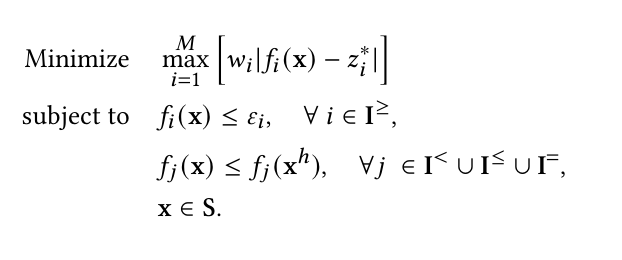

In [110]:
import numpy as np
from pymoo.algorithms.so_genetic_algorithm import GA
from pymoo.factory import get_termination
from pymoo.optimize import minimize

def STEM_SubProblem_Browser(problem, pop_size, n_gen, STEM_Start_X, STEM_Start_F, parameters, I_dict,
                            ideal_point, nadir_point, ann1_data, ann2_data, scaler_json, xl=0.0, xu=1.0):
    """
    Executes the high-fidelity legacy Pymoo GA single-objective optimization engine 
    combined with the corrected multi-task browser neural network evaluator.
    """
    # 1. Unpack preference groups cleanly from the dictionary tracker
    i1, i2, i3, i4 = I_dict[1], I_dict[2], I_dict[3], I_dict[4]

    # Instantiate the exact STEM subproblem mathematical wrapper
    STEM_Method_SubProblem = STEM_Problem(
        problem=problem, start_F=STEM_Start_F, eps=parameters, 
        i1=i1, i2=i2, i3=i3, i4=i4, mode='sub', 
        ideal_point=ideal_point, nadir_point=nadir_point
    )
    
    # 2. Configure Pymoo GA Properties
    algorithm = GA(pop_size=pop_size, eliminate_duplicates=True)
    termination = get_termination("n_gen", n_gen) 
    
    print("=" * 100)
    print("Running high-fidelity optimization via Pymoo GA Engine...")
    
    res_STEM_SubProb = minimize(
        STEM_Method_SubProblem,
        algorithm,
        termination=termination,
        seed=1,          
        verbose=False
    )
    
    print("Optimization for STEM Subproblem Completed ...")
    
    # 3. Handle structure property check dimensions
    n_ieq_constr = getattr(problem, "n_ieq_constr", 0)
    n_eq_constr = getattr(problem, "n_eq_constr", 0)
    n_obj = getattr(problem, "n_obj", 0)
    n_cons = n_ieq_constr + n_eq_constr
    
    # Fallback assignment loop logic 
    if res_STEM_SubProb.X is None:
        print("No solution found for given class ...\n Setting to Previous Solution")
        STEM_SubProb_X = STEM_Start_X 
        STEM_SubProb_F = STEM_Start_F 
    else:
        STEM_SubProb_X = res_STEM_SubProb.X
        print("STEM Subproblem X:", STEM_SubProb_X)
        
        # Safely evaluate using the vector problem's underlying _evaluate dictionary pattern
        base_problem_out = {}
        problem._evaluate(np.atleast_2d(STEM_SubProb_X), base_problem_out)
        
        # Grab objective space layout array
        F_array = base_problem_out.get("F")
        STEM_SubProb_F = F_array[0] if F_array.ndim > 1 else F_array
        print("STEM Subproblem F:", STEM_SubProb_F)

    # 4. Route design metrics safely via the shape-pure parallel browser function
    pred_class, pred_params, I_new = Output_MachDM_Pref_Browser(
        ann1_data=ann1_data, 
        ann2_data=ann2_data, 
        scaler_json=scaler_json,
        X_current=np.atleast_2d(STEM_SubProb_X)
    )
    
    # 5. Extract subproblem constraint values via the correct _evaluate pattern
    stem_eval_out = {}
    STEM_Method_SubProblem._evaluate(np.atleast_2d(STEM_SubProb_X), stem_eval_out)
    STEM_SubProb_G1 = stem_eval_out.get("G", np.empty(0))
    
    # Squeeze out structural batches down to singular individual lines
    if STEM_SubProb_G1.ndim > 1:
        STEM_SubProb_G1 = STEM_SubProb_G1[0]
    
    if n_cons >= 1 and STEM_SubProb_G1.size > 0:
        STEM_SubProb_G = STEM_SubProb_G1[n_cons : n_cons + n_obj]
    else:
        STEM_SubProb_G = STEM_SubProb_G1
        
    print("STEM Subproblem G:", STEM_SubProb_G)
    print("Objective Classifications from ANN1:", pred_class)
    print('Parameters from ANN2:', pred_params)
    print("Class-wise Objectives i's:", I_new)
    
    return STEM_SubProb_X, STEM_SubProb_F, STEM_SubProb_G, pred_class, pred_params, I_new

## Plot MCDM Solutions

In [111]:
import numpy as np
import matplotlib.pyplot as plt

def plot_MCDM_Solns(soln):
    # Enforce 2D array formatting so that slicing soln[:, 0] and soln[:, 1] never throws an IndexError
    soln = np.atleast_2d(soln)
    
    plt.figure(figsize=(5.5, 5.5))
    ideal_point = np.min(pf, axis=0)
    nadir_point = np.max(pf, axis=0)
    
    # 1. Base Scatter layers
    plt.scatter(pf[:, 0], pf[:, 1], s=10, label='Pareto Front', edgecolor='k', facecolor='w', alpha=1)
    plt.scatter(soln[:, 0], soln[:, 1], s=100, label='Current Solution', edgecolor='k', facecolor='b', alpha=1)
    plt.scatter(pf[idx, 0], pf[idx, 1], s=150, label='Target Solution', edgecolor='k', facecolor='r', alpha=1)

    # 2. Vertical boundary lines (f1 axis partitions)
    plt.axvline(x=eps[0], color='r', linewidth=1.5, linestyle=':')
    plt.text(eps[0] + 0.35, 0.15, r'$I^{<}:1$', rotation=90, color='k', va='center', fontsize=12)
    plt.text(eps[0] - 0.55, 0.15, r'$I^{\leq}:2$', rotation=90, color='k', va='center', fontsize=12)

    plt.axvline(x=Fin_F[0] + delta[0], color='y', linewidth=1.5, linestyle=':')
    plt.axvline(x=Fin_F[0] - delta[0], color='y', linewidth=1.5, linestyle=':')
    plt.text(Fin_F[0] + delta[0] - 0.30, 0.15, r'$I^{=}:3$', rotation=90, color='k', va='center', fontsize=12)

    plt.axvline(x=d[0], color='g', linewidth=1.5, linestyle=':')
    plt.text(d[0] - 1.35, 0.15, r'$I^{\geq}:4$', rotation=90, color='k', va='center', fontsize=12)

    # 3. Horizontal boundary lines (f2 axis partitions)
    plt.axhline(y=eps[1], color='r', linewidth=1.5, linestyle=':')
    plt.text(7, eps[1] + 0.35, r'$I^{<}:1$', rotation=0, color='k', va='center', fontsize=12)
    plt.text(7, eps[1] - 0.35, r'$I^{\leq}:2$', rotation=0, color='k', va='center', fontsize=12)

    plt.axhline(y=Fin_F[1] + delta[1], color='y', linewidth=1.5, linestyle=':')
    plt.axhline(y=Fin_F[1] - delta[1], color='y', linewidth=1.5, linestyle=':')
    plt.text(7, Fin_F[1] + delta[1] - 1.30, r'$I^{=}:3$', rotation=0, color='k', va='center', fontsize=12)

    plt.axhline(y=d[1], color='g', linewidth=1.5, linestyle=':')
    plt.text(7, d[1] - 1.35, r'$I^{\geq}:4$', rotation=0, color='k', va='center', fontsize=12)

    # 4. Reference point and Ideal point landmarks
    plt.scatter(ref_point[0], ref_point[1], s=150, marker='*', edgecolor='k', facecolor='k', alpha=1)
    plt.scatter(ideal_point[0], ideal_point[1], s=80, edgecolor='k', facecolor='k', alpha=1)

    plt.plot([ideal_point[0], ref_point[0]], [ideal_point[1], ref_point[1]], 'bo', linestyle="--")
    plt.plot([ideal_point[0]], [ideal_point[1]], 'mo', linestyle="--")
    
    plt.text(0.95 * ref_point[0], 1.05 * ref_point[1], r"$R$", fontsize=14)
    plt.text(ideal_point[0] - 0.4, ideal_point[1] - 0.4, r"$O$", fontsize=14)
    
    # 5. Label your solutions dynamically (A, B, C...)
    c = 0.035 * (nadir_point - ideal_point)
    labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T']
    for (x, y), label in zip(soln, labels):
        plt.text(x + c[0], y + c[1], label, fontsize=14, ha='center', va='center', color='blue')

    # 6. Plot configurations
    plt.legend(["Pareto Front", "MCDM Solution", "Target Solution"], loc="upper center", fontsize=10)
    plt.xlabel(r'$f_1$', fontsize=14)
    plt.ylabel(r'$f_2$', fontsize=14)
    plt.grid(color='k', linestyle='--', linewidth=1, alpha=0.15)
    plt.show()

In [112]:
def start_point_generator(xl, xu, RNG):
    rng = np.random.default_rng(RNG)
    random_x = rng.uniform(low=xl, high=xu)
    return random_x

## Start Point

Running high-fidelity initialization via Pymoo GA Engine...
Optimization Completed ...
Start Point X: [0. 0. 0. 0. 0.]
Start Point F: [0.  7.7]
Objective Classifications: [4, 1]
Parameters: [0.8597622219706609, 6.697900933068374]
Class-wise Objectives i's: {1: [1], 2: [], 3: [], 4: [0]}


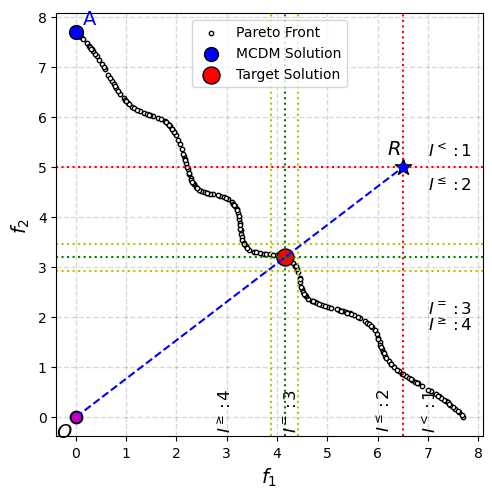

In [143]:
problem = knee_problem
pop_size = 100
n_gen = 200
xl = problem.xl
xu = problem.xu
RNG = 142
Start_point_X = start_point_generator(xl, xu, RNG)
# Start_point_X = np.array([1.0,0,0,0,0]) # Right bottom point
# Start_point_X = np.array([0.0,1.0,0,0,0]) # Left top point

# Run optimization block
STEM_Start_X, STEM_Start_F, pred_class, pred_params, I = STEM_Start_Point_Browser(
    problem, Start_point_X, pop_size, n_gen, xl, xu, ideal_point, nadir_point, 
    ann1_data, ann2_data,scaler_json)

# Extract objective space coordinates [f1, f2] explicitly for plotting
base_out = {}
problem._evaluate(np.atleast_2d(STEM_Start_X), base_out)
soln = np.array(base_out.get("F"))

plot_MCDM_Solns(soln)

## Compute Next Point 

Running high-fidelity optimization via Pymoo GA Engine...
Optimization for STEM Subproblem Completed ...
No solution found for given class ...
 Setting to Previous Solution
STEM Subproblem G: [0. 0.]
Objective Classifications from ANN1: [3, 3]
Parameters from ANN2: [4.081881143292861, 3.2300767275669475]
Class-wise Objectives i's: {1: [], 2: [], 3: [0, 1], 4: []}


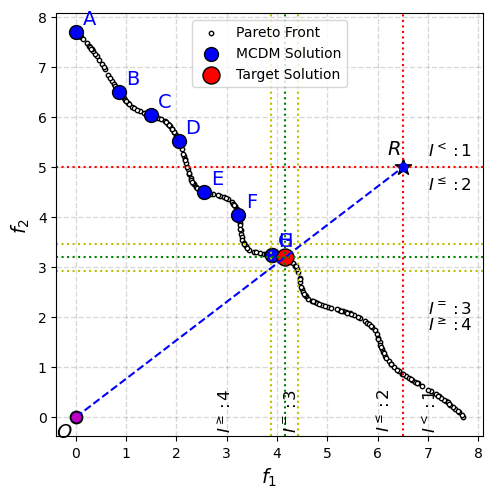

In [150]:
import numpy as np
from IPython.display import display, HTML

# 1. Update start states if a multi-point solution history exists
if np.size(soln, 0) > 1:
    STEM_Start_X = STEM_SubProb_X
    STEM_Start_F = STEM_SubProb_F

# 2. Run the browser-safe NumPy STEM subproblem optimization phase
# Swapped model1, model2, scalers for your pre-parsed numpy weight dictionaries
STEM_SubProb_X, STEM_SubProb_F, STEM_SubProb_G, pred_class, pred_params, I = STEM_SubProblem_Browser(
    problem=problem,
    pop_size=pop_size,
    n_gen=n_gen,
    STEM_Start_X=STEM_Start_X,
    STEM_Start_F=STEM_Start_F,
    parameters=pred_params,
    I_dict=I,
    ideal_point=ideal_point,
    nadir_point=nadir_point,
    ann1_data=ann1_data,
    ann2_data=ann2_data,
    scaler_json=scaler_json,
    xl=xl,
    xu=xu
)

# 3. Display termination condition updates
if np.all(np.array(pred_class) >= 3):
    display(HTML("<h2 style='color:green;font-size:30px;'>Target solution is found. STOP!</h2>"))
else:
    display(HTML("<h2 style='color:red;font-size:30px;'>Run the above cell again!</h2>"))
    
# 4. FIX: Safely extract the raw multi-objective coordinate pair [f1, f2] for the new point
base_out = {}
problem._evaluate(np.atleast_2d(STEM_SubProb_X), base_out)
new_soln_point = np.array(base_out.get("F"))  # Yields a clean (1, 2) shape

# Append the new vector coordinates to your historical plot matrix
soln = np.concatenate([soln, new_soln_point], axis=0)

# 5. Render the step-by-step progress scatter plot
plot_MCDM_Solns(soln)

